# Network Connectivity Check — PyPSA-Earth (Senegal)

Checks node connectivity ("degree" = number of distinct lines/links/transformers touching a bus) in a PyPSA-Earth network, to help identify nodes that may be under-connected due to gaps in the underlying OpenStreetMap data (see PyPSA-Earth Section 3.8, "Augmented line connection").

**Why this matters:** PyPSA-Earth builds transmission topology from OpenStreetMap, which is often less meshed than the real grid, especially in regions with sparse open data coverage. Nodes with degree 0 (no lines at all) will break a dispatch/LOPF optimization, since they cannot exchange power with the rest of the network. Nodes with degree 1 (dead-ends) may be genuine radial spurs — or they may be missing a real connection that just isn't in OSM. This notebook flags both cases so you can inspect them before deciding whether to run PyPSA-Earth's k-edge augmentation step (adding minimal-capacity, e.g. 1 MW, placeholder lines) to patch the topology.

**Before running:** use your PyPSA-Earth conda environment as the notebook kernel (so `pypsa` is already installed).

## 1. Settings

Edit the path and threshold below, then run all cells.

In [8]:
NETWORK_PATH = "networks/elec.nc"  # <-- point this at your clustered Senegal network
MIN_DEGREE = 2                           # flag nodes with fewer connections than this
CSV_OUT = "node_connectivity_report.csv"
PLOT_OUT = "network_connectivity_map.png"


## 2. Load the network

In [9]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

n = pypsa.Network(NETWORK_PATH)

assert len(n.buses) > 0, f"No buses found in {NETWORK_PATH} -- is this a valid PyPSA network file?"
print(f"Loaded network with {len(n.buses)} buses, {len(n.lines)} lines, {len(n.links)} links, {len(n.transformers)} transformers.")


INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, transformers


Loaded network with 28 buses, 25 lines, 0 links, 4 transformers.


## 3. Compute node degree

Counts the number of distinct lines (AC), links (e.g. HVDC), and transformers touching each bus.

In [10]:
def compute_degree(n):
    degree = pd.Series(0, index=n.buses.index, dtype=int)

    for _, row in n.lines.iterrows():
        degree[row.bus0] += 1
        degree[row.bus1] += 1

    if len(n.links) > 0:
        for _, row in n.links.iterrows():
            degree[row.bus0] += 1
            degree[row.bus1] += 1

    if len(n.transformers) > 0:
        for _, row in n.transformers.iterrows():
            degree[row.bus0] += 1
            degree[row.bus1] += 1

    return degree

degree = compute_degree(n)
degree.head()


Bus
0    4
1    3
2    3
3    1
4    2
dtype: int64

## 4. Classify nodes

In [11]:
def classify(degree, min_degree):
    def flag(d):
        if d == 0:
            return "ISOLATED (no lines at all -- will break the optimization)"
        elif d == 1:
            return "DEAD-END (single connection -- check if this is a real radial spur)"
        elif d < min_degree:
            return f"UNDER-CONNECTED (< {min_degree} connections)"
        else:
            return "ok"
    return degree.apply(flag)

status = classify(degree, MIN_DEGREE)
status.value_counts()


ok                                                                     18
DEAD-END (single connection -- check if this is a real radial spur)     9
ISOLATED (no lines at all -- will break the optimization)               1
Name: count, dtype: int64

## 5. Summary

In [12]:
print("=== Node degree distribution ===")
print(degree.value_counts().sort_index().to_string())

n_isolated = (degree == 0).sum()
n_deadend = (degree == 1).sum()
total = len(degree)

print(f"\nTotal buses: {total}")
print(f"Isolated (degree 0): {n_isolated}  ({n_isolated/total:.1%})")
print(f"Dead-end (degree 1): {n_deadend}  ({n_deadend/total:.1%})")

if n_isolated > 0:
    print("\n⚠ Isolated nodes will make the LOPF/dispatch optimization infeasible or force "
          "unrealistic local-only balancing. These need augmentation or a data fix before "
          "running the baseline.")
if n_deadend > 0:
    print("⚠ Dead-end nodes are not necessarily wrong (radial spurs are real), but each one "
          "is worth a quick visual check against a real grid map to rule out a missing OSM connection.")


=== Node degree distribution ===
0    1
1    9
2    9
3    5
4    4

Total buses: 28
Isolated (degree 0): 1  (3.6%)
Dead-end (degree 1): 9  (32.1%)

⚠ Isolated nodes will make the LOPF/dispatch optimization infeasible or force unrealistic local-only balancing. These need augmentation or a data fix before running the baseline.
⚠ Dead-end nodes are not necessarily wrong (radial spurs are real), but each one is worth a quick visual check against a real grid map to rule out a missing OSM connection.


## 6. Full report table

Sorted worst-first (lowest degree at the top) so the nodes needing attention are immediately visible.

In [13]:
report = pd.DataFrame({
    "bus": degree.index,
    "degree": degree.values,
    "status": status.values,
    "x": n.buses.x.values,
    "y": n.buses.y.values,
}).sort_values("degree")

report.to_csv(CSV_OUT, index=False)
print(f"Full report written to {CSV_OUT}")
report.head(20)


Full report written to node_connectivity_report.csv


,bus,degree,status,x,y
22,22,0,ISOLATED (no lines at all -- will break the op...,-15.4657,12.6558
27,27,1,DEAD-END (single connection -- check if this i...,-15.9745,15.9565
24,24,1,DEAD-END (single connection -- check if this i...,-16.2227,12.5578
3,3,1,DEAD-END (single connection -- check if this i...,-16.9502,14.4705
23,23,1,DEAD-END (single connection -- check if this i...,-17.0645,14.7627
7,7,1,DEAD-END (single connection -- check if this i...,-16.6199,15.1462
9,9,1,DEAD-END (single connection -- check if this i...,-12.4689,14.8919
11,11,1,DEAD-END (single connection -- check if this i...,-16.4163,14.3663
16,16,1,DEAD-END (single connection -- check if this i...,-16.8468,15.0973
26,26,1,DEAD-END (single connection -- check if this i...,-12.2071,14.4682


## 7. Map

Red = isolated, orange = dead-end, blue = ok. Cross-check flagged nodes' coordinates against a real Senelec grid map before deciding whether to patch them.

n.plot() failed (The passed axis is not a GeoAxesSubplot. You can ), falling back to a plain scatter plot.
Saved connectivity map to network_connectivity_map.png


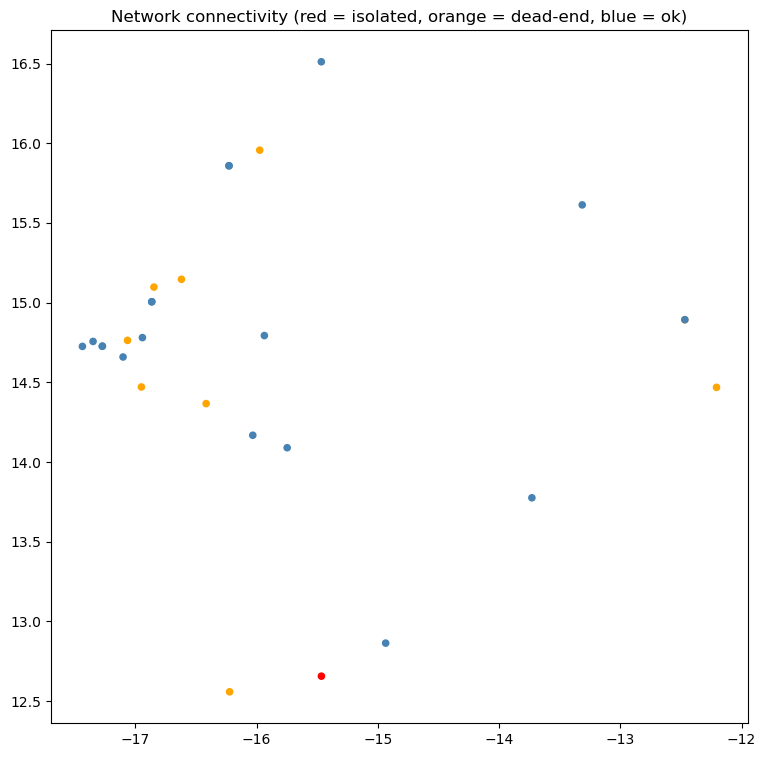

In [14]:
colors = degree.map(lambda d: "red" if d == 0 else ("orange" if d == 1 else "steelblue"))

fig, ax = plt.subplots(figsize=(9, 9))
try:
    n.plot(
        ax=ax,
        bus_colors=colors,
        bus_sizes=0.02,
        line_widths=0.5,
        title="Network connectivity (red = isolated, orange = dead-end, blue = ok)",
    )
except Exception as e:
    print(f"n.plot() failed ({e}), falling back to a plain scatter plot.")
    ax.scatter(n.buses.x, n.buses.y, c=colors, s=20)
    ax.set_title("Network connectivity (red = isolated, orange = dead-end, blue = ok)")

fig.savefig(PLOT_OUT, dpi=150, bbox_inches="tight")
print(f"Saved connectivity map to {PLOT_OUT}")
plt.show()


## 8. Next steps

- Inspect any `ISOLATED` or `DEAD-END` rows in the report table above.
- Cross-reference their `x`/`y` coordinates against a real map of Senelec's transmission grid.
- If a flagged node is a genuine gap in OSM (not a real radial spur), consider running PyPSA-Earth's k-edge augmentation to add a minimal-capacity (e.g. 1 MW) placeholder line, the same fix used in the Nigeria validation case — and document exactly which connections you added and why, since this is a modelling assumption worth disclosing in your methodology.